# Introduction aux graphes et leurs structures de données

## Graphes: quelques définitions

Qu'y a t'il de commun entre tous nos problèmes?

<!--TODO: figure!-->

Dans chacun d'entre eux, la résolution se ramènera à étudier comment certains objets sont
reliés entre eux. Autrement dit, le problème va pouvoir être **modélisé à l'aide d'un
graphe**.

Informellement: un ***graphe*** est la donnée d'un ensemble de ***sommets*** reliés par
des ***arêtes***. Voilà un exemple avec cinq sommets. Les sommets 1 et 3 y sont reliés
entre eux. Mais pas 1 et 4.

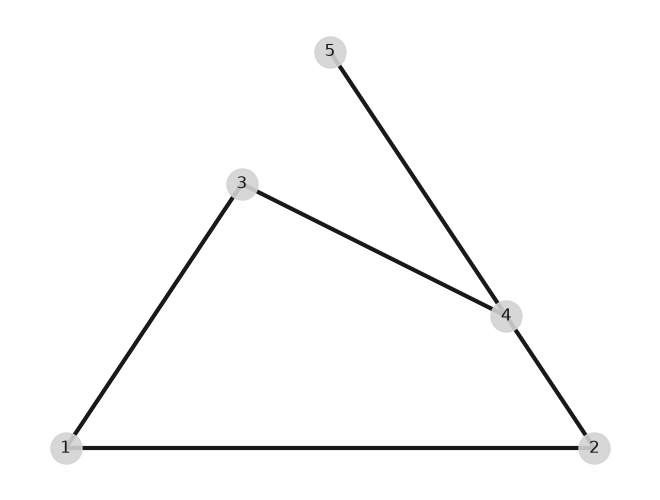

In [1]:
import graph_networkx
G = graph_networkx.Graph(nodes=[1, 2, 3, 4, 5],
                         edges=[ (1,2), (1,3), (2,4), (3,4), (4,5) ])
G.show()

La définition formelle la plus simple est la suivante:

:::{admonition} Définition
Un ***graphe*** est une paire $G:=(V,A)$ où $V$ est un ensemble et $A$ et un ensemble de
paires $\{v_1,v_2\}$ d'éléments de $V$.
:::

Dans notre exemple, $G=(V,A)$, où $V = \{1,2,3,4,5\}$ et
$A = \{\{1,2\}, \{1,3\}, \{2,4\}, \{3,4\}, \{4,5\} \}$.

:::{admonition} Remarque
Dans la définition donnée, une arête est un ensemble à deux éléments:

- le graphe n'est ***pas orienté***: si $s$ est relié à $t$ alors $t$ est relié à $s$;
- il n'y a pas de ***boucle***, c'est à dire une arête reliant un sommet à lui-même;
- ni d'***arête multiple***, c'est-à-dire plusieurs arêtes reliant les mêmes sommets;

On parle de ***graphe simple***.
:::

## Graphes: variantes

Le plus souvent, cette information de base est enrichie d'informations supplémentaires:
étiquettes sur les sommets, valuations sur les arêtes, orientation des arêtes, ...

On remplace la paire $\{v_1,v_2\}$ par un couple $(v_1,v_2)$ :

- On a en plus: orientation, boucle...

On ajoute un nombre à la paire $(v_1, v_2, c)$ :

- On a en plus: arête multiple, coût, capacité ...

## Quelques structures de données pour les graphes

Pour étudier un graphe à l'aide d'un ordinateur, il va falloir le représenter,
c'est-à-dire choisir une structure de données. Comme le champ d'application des graphes
et large, il y a beaucoup d'algorithmes différents, avec des besoins différents en terme
de performance des opérations élémentaires. Tel algorithme va demander d'avoir un accès
très performant aux voisins d'un sommet; tel autre parcourir les arêtes, etc. De ce fait,
il existe de nombreuses structures de données possibles que nous allons explorer
maintenant.

:::{attention}
On s'intéressera dans cette séance aux ***graphes orientés*** où chaque arête aura une
capacité `c` qui sera un nombre.
:::

### Liste d'arêtes

Ici, on représentera un graphe par une liste de triplets `(v1,v2,c)`, chacun d'entre eux
spécifiant qu'il y a une arête reliant $v_1$ à $v_2$ de capacité $c$.

Ci-dessous, nous donnons la structure de données `L0` d'un graphe $G_0$ avec trois
sommets, $0,1,2$, et deux arêtes; la première relie $0$ à $1$ avec une capacité de $10$
et la deuxième relie $0$ à $2$ avec une capacité de $4$.

In [2]:
L0 = [ (0,1,10), (0,2,4) ]

Voici la structure de donnée pour un autre graphe $G_1$:

In [3]:
L1 = [ (1,2,1), (1,3,1), (2,4,2), (3,4,0), (4,5,3) ]

:::{admonition} Exercice
Dessinez sur papier les graphes `G_0` et `G_1`, en mettant sur chaque arête sa capacité.
:::

Pour chaque structure de données de ce cours, un type (laxiste) est fourni. Ici, ce sera:

In [4]:
graph_networkx.EdgeList

typing.Sequence[typing.Tuple[typing.Any, typing.Any, typing.Any]]

Ce type peut par exemple être utilisé pour typer statiquement du code ou pour faire des
vérifications dynamiques:

In [5]:
from typeguard import check_type
assert check_type(L1, graph_networkx.EdgeList)

### Rappel: dictionnaires Python

Un *dictionnaire* en Python est une structure de donnée permettant d'associer à une
valeur à une clé. Comme un dictionnnaire de français qui associe une définition à un mot,
ou un annuaire qui associe un numéro de téléphone à une personne. Voici un dictionnaire
qui associe la valeur `1` à la clé `"bla"`, la valeur `3` à la clé `"ble"` et la valeur
`"pi"` à la clé `3.13`:

In [6]:
t = {"bla": 1, "ble": 3, 3.14: "pi"}

In [7]:
t

{'bla': 1, 'ble': 3, 3.14: 'pi'}

On peut accéder à une valeur à partir de sa clé avec l'opération suivante:

In [8]:
t[3.14]

'pi'

On notera la similitude avec l'accès aux éléments d'un tableau. On peut voir un tableau
de taille `l` comme un dictionnaire associant des valeurs à des clés entre `0` et `l-1`

### Dictionnaire des voisins

Un sommet $v_2$ est un voisin sortant d'un sommet $v_1$ s'il y a une arête reliant $v_1$
à $v_2$.

On peut représenter un graphe à l'aide d'un ***dictionnaire des voisins*** qui à chaque
sommet associe la liste de ses voisins. Comme on veut représenter des capacités, la
valeur associée à la clé `v1` sera un liste de paires `(v2,c)` où $v_2$ sera le voisin et
`c` la capacité de l'arête reliant $v_1$ à $v_2$.

Voici le dictionnaire des voisins pour $G_0$:

In [9]:
DV0 = { 0: [(1,10), (2,4) ] }

:::{admonition} Exercice
Donnez le dictionnaire des voisins pour $G_1$, et stockez le dans la variable `DV1`:
:::

In [10]:
# Cellule cell-d662314d2272933e
# REMPLACEZ TOUTE CETTE LIGNE PAR VOTRE CODE

In [11]:
assert check_type(DV1, graph_networkx.NeighborDict)
assert sorted(L1) == sorted( (i,j, w) for i, l in DV1.items() for [j,w] in l )

NameError: name 'DV1' is not defined

:::{note}
Si les sommets du graphe sont étiquetés par $0,1,\ldots$, on peut utiliser une liste au
lieu d'un dictionnaire :
:::

In [12]:
# Avec un tableau (graphe etiquete par 0,1,...)
DV0 = [ [(1,10), (2,4)] ]

### Dictionnaire d'arêtes

Utilisons maintenant un ***dictionnaire d'arêtes*** pour représenter `G_1` : il associera
à chaque paire `(u1,v1)` reliés par une arête la capacité de cette arrête.

Voici le dictionnaire pour $G_0$:

In [13]:
DA0 = { (0,1): 10,
        (0,2): 4
      }

:::{admonition} Exercice
Donnez le dictionnaire d'arêtes pour $G_1$.
:::

In [14]:
# Cellule cell-98fa5972274a0bce
# REMPLACEZ TOUTE CETTE LIGNE PAR VOTRE CODE

In [15]:
assert check_type(DA1, graph_networkx.EdgeDict)
assert sorted(L1) == sorted((i, j, c) for (i, j), c in DA1.items())

NameError: name 'DA1' is not defined

## Matrice d'adjacence

La ***matrice d'adjacence*** d'un graphe est un tableau (ou matrice) à deux dimensions
`M` tel que `M[v1,v2]` est la capacité `c` de l'arête reliant $v_1$ à $v_2$ ou $0$ s'il
n'y a pas d'arête.

In [16]:
M0 = [ [0, 10, 4],
       [0,  0, 0],
       [0,  0, 0]]

::::{admonition} Exercice
Donnez la matrice d'adjacence pour $G_1$.

:::{admonition} Indication
:class: tip dropdown

- Vous rajouterez un sommet $0$ (pourquoi?).
- Rappel: Le graphe est orienté.
:::
::::

In [17]:
# Cellule cell-9caa44fcb3382c31
# REMPLACEZ TOUTE CETTE LIGNE PAR VOTRE CODE

In [18]:
assert check_type(M1, graph_networkx.AdjacencyMatrix)
assert len(M1) == 6
assert all(len(M1[i]) == 6 for i in range(6))
assert sum( M1[i][j] for i in range(6) for j in range(6) ) == 7

NameError: name 'M1' is not defined

# Conclusion

Maintenant que vous avez manipulé des structures de données de graphes sur des exemples,
vous pouvez passer à la feuille suivante.